In [2]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os

import joypy



In [3]:
#load data and extract lick times
def get_licks_df(path):
    stim_dur = 1
    f=open(path, 'rb')
    objs = []
    while 1:
        try:
            objs.append(pickle.load(f))
        except:
            break
    f.close()

    #extracting the start of water delivery ('r')
    rew_time_ls = [x.split("r")[1].split(" ")[0].split("u")[0] for x in objs]

    #converting the string to to an array
    rew_time_ar = np.array(rew_time_ls, dtype=np.float32)

    #subtracting the stimulus duration
    stim_times = rew_time_ar - stim_dur
    stim_times #start times of the stimulus - this is our 0 time point

    #removing the 'u' and 'r' identifiers
    cleaned_objs = [ x.replace('u', ' ') for x in objs if 'u' in x ]
    cleaned_objs = [ x.replace('r',' ') for x in cleaned_objs if 'r' in x ]

    lick_times = [np.array(x.strip().split(" "), dtype=np.float32) for x in cleaned_objs ]

    for idx, val in enumerate(rew_time_ar):
        lick_times[idx] =  lick_times[idx][lick_times[idx] != val]

    df_licks = pd.DataFrame(lick_times).sub(stim_times, axis = 0)

    # remove the first stimulus because of the massive delay present in the recording
    # its the delay used to position the delivery so that the mouse doesn't get the massive flow
    df_licks.drop(df_licks.index[0], inplace=True)

    df_licks2 = pd.DataFrame(df_licks.stack())
    return df_licks2

In [4]:
#load data and extract lick times

# This is the path that should work on windows OS to access the U drive and the correct file
# path = r"U:\Data\zimmer94\Behavior_rigs\licks\03.20.21\CC077837_HP1_pav_2021-03-20_13-29-26.pkl"

# This is the path that Rachel uses on her MacBook to access the U drive and the correct file
path = r"/Volumes/bio_mousevision/Data/zimmer94/Behavior/licks/06.10.21/CC067431_HP1_inter_2021-06-10_12-49-34.pkl"




In [5]:
# isolate CC number from the path name
CC_num = path.split("/")[-1].split("_")[0]

# isolate head plate number from the path name
HP_num = path.split("/")[-1].split("_")[1]

# splice the isolated CC number and head plate number together
mouse = str(CC_num + ' ' + HP_num)
print('Mouse:', mouse)

# isolate the paradigm type from the path name
paradigm = path.split("/")[-1].split("_")[2]
print('Paradigm:', paradigm)

# define the stimulus time and reward times within each trial according to paradigm
    # Start with the files from 06.10.21, they should be the 'inter' paradigm

if paradigm == 'pav':
    stim_lb = 0.0 #lower bound of stimulus time
    stim_ub = 1.0 #upper bound of stimulus time
    rew_lb = 1.0
    rew_ub = 1.2
    stim_dur = 1.0
elif paradigm == 'inter':
    stim_lb = 0.0 #lower bound of stimulus time
    stim_ub = 0.2 #upper bound of stimulus time
    rew_lb = stim_ub+0.5
    rew_ub = stim_ub+0.5+0.2
    stim_dur = 0.2
elif paradigm == 'inter2':
    stim_lb = 0.0 #lower bound of stimulus time
    stim_ub = 0.2 #upper bound of stimulus time
    rew_lb = stim_ub+1.5
    rew_ub = stim_ub+1.5+0.2
    stim_dur = 0.2



Mouse: CC067431 HP1
Paradigm: inter


In [6]:
# Run the function and update dataframe columns
df_licks2 = get_licks_df(path)

df_licks2 = df_licks2.reset_index()
df_licks2.columns = ["trial", "lick_idx", "lick_time"]

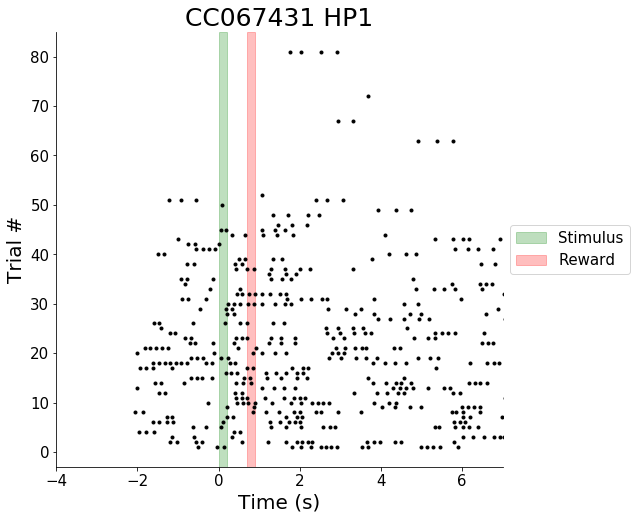

In [7]:
# Plot licks across trials in the form of a dot plot
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8.0 # x dimension
fig_size[1] = 8.0 # y dimension

plt.plot( df_licks2.lick_time.values, df_licks2.trial, 'k.', label='_nolegend_')
sns.despine()

plt.xlim(-4, 7)
plt.axvspan(stim_lb,stim_ub, color='green', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='red', alpha=0.25) 

plt.title(mouse,fontsize=25)
plt.xlabel('Time (s)',fontsize=20)
plt.ylabel('Trial #',fontsize=20)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(('Stimulus','Reward'),loc='center left', bbox_to_anchor=(1,0.5), prop={'size': 15})

# Saving the figure to the appropriate folder in the U drive

    # Use the first part of the path you defined earlier in the code but then send it to the data_analysis folder, then the behavior_analysis folder, and name it appropriately
    # Change the end to a new file name!!
plt.savefig("/Volumes/bio_mousevision/Data_Analysis/zimmer94/Behavior_analysis/CC067431_lick_graphs/day_1_training_dotplot", bbox_inches='tight', transparent=True)

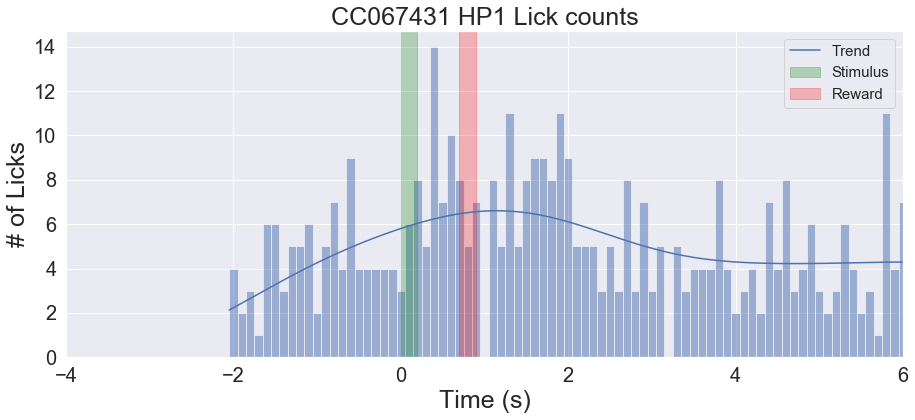

In [8]:
# Plot the lick count histogram
sns.set(rc={'figure.figsize':(15,6)})
hist = sns.histplot(df_licks2.lick_time.values, binwidth=0.1, kde=True, legend=False)


hist.set(xlabel="Lick time (s)", ylabel="Number of licks")
plt.axvspan(stim_lb,stim_ub, color='green', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='red', alpha=0.25) 
plt.legend(('Trend','Stimulus','Reward'), prop={'size': 15})
#plt.suptitle(mouse, fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.title(mouse+" Lick counts", fontsize=25)
plt.xlabel("Time (s)", fontsize=25)
plt.ylabel('# of Licks', fontsize=25)
plt.xlim(-4, 6)

#saving the figure to the appropriate folder in the U drive
    # Change the end of this next line with a new file name!!
    # Same idea as the saving process in the cell above
plt.savefig("/Volumes/bio_mousevision/Data_Analysis/zimmer94/Behavior_analysis/CC067431_lick_graphs/day_1_training_lickcounts_hist", bbox_inches='tight', transparent=True)


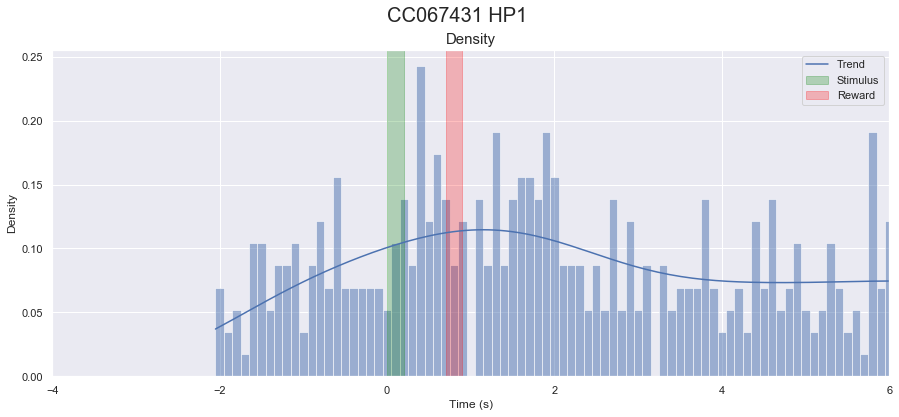

In [9]:
# Plot the lick density histogram which gives a plot of licks across all trials for the day
sns.set(rc={'figure.figsize':(15,6)})
hist = sns.histplot(df_licks2.lick_time.values, binwidth=0.1, kde=True, legend=False, stat="density")

hist.set(xlabel="Lick time (s)", ylabel="Density")
plt.axvspan(stim_lb,stim_ub, color='green', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='red', alpha=0.25) 
plt.legend(('Trend','Stimulus','Reward'))
plt.suptitle(mouse, fontsize=20)
plt.title("Density", fontsize=15)
plt.xlabel("Time (s)")
plt.xlim(-4, 6)

#saving the figure to the appropriate folder in the U drive
    # Change the end of this next line with a new file name!!
    # Same idea as the saving process in the cell above
plt.savefig("/Volumes/bio_mousevision/Data_Analysis/zimmer94/Behavior_analysis/CC067431_lick_graphs/day_1_training_density_hist", bbox_inches='tight', transparent=True)



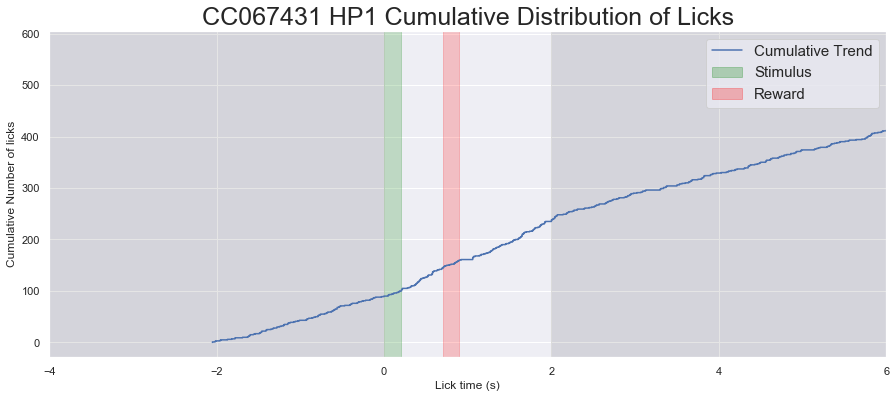

In [10]:
# Plot the cumulative distribution of licks across trials for the day
sns.set(rc={'figure.figsize':(15,6)})
sumc = sns.ecdfplot(data=df_licks2.lick_time.values, stat="count",legend=False)
sumc.set(xlabel="Lick time (s)", ylabel="Cumulative Number of licks")


plt.axvspan(stim_lb,stim_ub, color='green', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='red', alpha=0.25) 
plt.legend(('Cumulative Trend','Stimulus','Reward'), prop={'size': 15})


plt.xlim(-4, 6)
plt.title(mouse+" Cumulative Distribution of Licks", fontsize=25)

seg1 = df_licks2[(df_licks2['lick_time']<0)]
seg2 = df_licks2[(df_licks2['lick_time']>=0) & (df_licks2['lick_time']<=2)]
seg3 = df_licks2[(df_licks2['lick_time']>2)]


plt.axvspan(-4,0, color='gray', alpha=0.2)
plt.axvspan(0,2, color = 'white', alpha=0.2)
plt.axvspan(2,6, color='gray', alpha=0.2)

#saving the figure to the appropriate folder in the U drive
    # Change the end of this next line with a new file name!!
    # Same idea as the saving process in the cell above
plt.savefig("/Volumes/bio_mousevision/Data_Analysis/zimmer94/Behavior_analysis/CC067431_lick_graphs/day_1_training_cumdist", bbox_inches='tight', transparent=True)



In [26]:
# Plot licks over days with a normalized licks/day heatmap
sns.set_context("poster")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["font.size"] = 1.5

In [27]:
# load data
# path = r"U:\Data\zimmer94\Behavior\licks"
path = r"/Volumes/bio_mousevision/Data/zimmer94/Behavior/licks"

paradigm = "inter"
# paradigm = "inter2"
# paradigm = "pav"

matches = []
for root, dirnames, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(('.pkl')) and paradigm in filename and "inter2" not in filename and "mouse" not in filename and "bad" not in filename and "bad" not in root:
            matches.append(os.path.join(root, filename))
print ("# of file matches:", len(matches))

matches[0]

# of file matches: 72


'/Volumes/bio_mousevision/Data/zimmer94/Behavior/licks/06.10.21/CC082257_HP2_inter_2021-06-10_13-22-57.pkl'

In [28]:
# taking the loaded files and creating a df from them
bins = np.arange(-2, 6.1, 0.1).round(3)
ls = []
for fn in matches[:]:
    try:
        tmp =  get_licks_df(fn) # this uses the same function as before!
        base = fn.split("/")[-1]
        #print(base)
        CC = base.split("_")[0]
        #print(CC)
        hp_n =  base.split("_")[1]
        #print(hp_n)
        paradigm = base.split('_')[2]
        counts, bins = np.histogram(tmp.values, bins = bins)
        dt = base.split('_')[-2]
        tmp_df = pd.DataFrame({"et": str(CC) + str(hp_n), 
                               "paradigm":paradigm, 
                               "lick_counts":counts, 
                               "bins":bins[:-1], 
                               "session": dt})
        ls.append(tmp_df)
    except:
        print ("not loaded:", fn)

main_df = pd.concat(ls)

not loaded: /Volumes/bio_mousevision/Data/zimmer94/Behavior/licks/06.14.21/CC082257_HP2_inter_2021-06-14_12-08-23.pkl
not loaded: /Volumes/bio_mousevision/Data/zimmer94/Behavior/licks/06.11.21/CC082257_HP1_inter_2021-06-11_10-46-34.pkl
not loaded: /Volumes/bio_mousevision/Data/zimmer94/Behavior/licks/06.11.21/CC067431_HP1_inter_2021-06-11_10-28-53.pkl
not loaded: /Volumes/bio_mousevision/Data/zimmer94/Behavior/licks/6.15.21/CC082263_HP2_inter_2021-06-15_09-24-21.pkl


In [29]:
main_df['session']= pd.to_datetime(main_df['session'])

print("Number of mice in this paradigm:",main_df['et'].nunique(), "\n")
print("Unique ET:", main_df['et'].unique())

Number of mice in this paradigm: 12 

Unique ET: ['CC082257HP2' 'CC082263HP3' 'CC082263HP2' 'CC067489HP3' 'CC067489HP1'
 'CC082263HP1' 'CC067489HP2' 'CC067431HP3' 'CC067431HP2' 'CC082257HP1'
 'CC082257HP3' 'CC067431HP1']


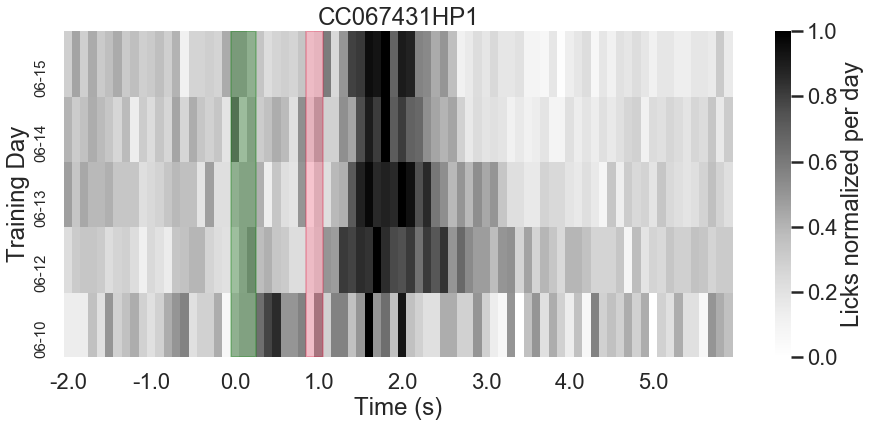

In [30]:
et = "CC067431HP1"

tmp = main_df[main_df.et == et]

# isolate the unique dates and sort them so they are ascending
dates = tmp.session.dt.strftime('%m-%d').unique()
dates = np.sort(dates,axis=0)

hm_inp = tmp.pivot_table(index='session',columns='bins', values='lick_counts', aggfunc=np.mean) #this is the heatmap input
max_ar = hm_inp.max(axis = 1).values
hm_inp = hm_inp.div(max_ar, axis = 0)
sns.heatmap(hm_inp, cmap = "Greys", 
            xticklabels=10, 
            yticklabels = dates,
            cbar_kws={'label': 'Licks normalized per day'})

plt.title(et)
plt.gca().invert_yaxis()
plt.xlabel('Time (s)')
plt.ylabel('Training Day')
plt.yticks(fontsize = 15)

if paradigm == "inter":
    plt.axvspan(20, 23, color = "green", alpha = 0.25)     #this is for interval training
    plt.axvspan(29, 31, color = "crimson", alpha = 0.25)   #this is for interval training
elif paradigm == "inter2":
    plt.axvspan(20, 23, color = "green", alpha = 0.25)     #this is for interval training
    plt.axvspan(35, 37, color = "crimson", alpha = 0.25)   #this is for interval training
elif paradigm == "pav":
    plt.axvspan(20, 30, color = "green", alpha = 0.25)     #this is for pav training
    plt.axvspan(30, 32, color = "crimson", alpha = 0.25)   #this is for pav training

plt.show()


# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\zimmer94\Data\DATA_Figs\Behavior\CC077877_HP1_0320_days.pdf", transparent=True)d

In [47]:
sns.set_context("poster")
plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.size"] = 22

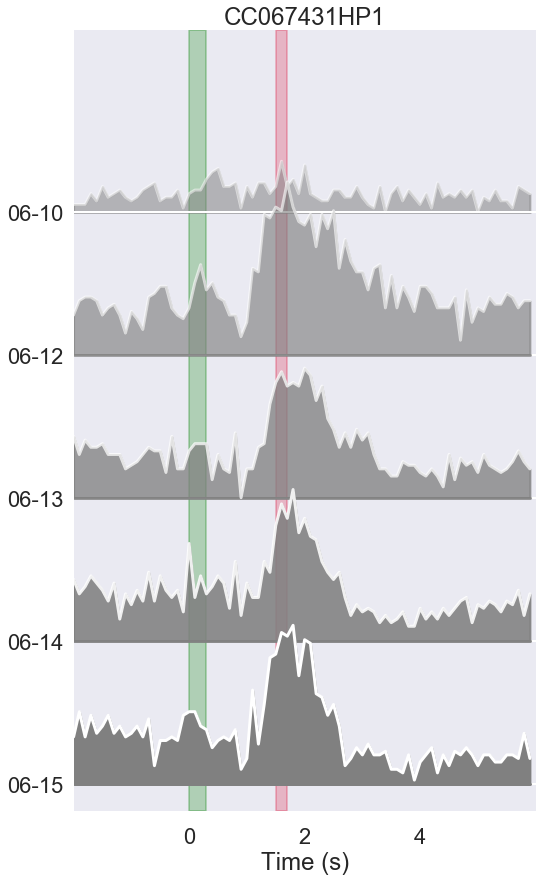

In [53]:
et = "CC067431HP1"

tmp = main_df[main_df.et == et]
# isolate the unique dates and sort them so they are ascending
dates = tmp.session.dt.strftime('%m-%d').unique()
dates = np.sort(dates,axis=0)
ylabels = dates
fig, axes = joypy.joyplot(tmp, by = "session", column ='lick_counts' , 
                              labels = ylabels,
#                               ylim = "own",
                              kind = "values",
                              grid = 'y', 
                              fade = 1,
#                               xlabels = [1, 2,3 ],
                              figsize = (8, 12),
#                               bins = 100,
                              x_range = list(range(81)),
#                               colormap = plt.cm.Pastel1,
                              linecolor = "white", color = "gray",
                              overlap = 0.6
                             )
axes[-1].set_xticklabels([0,2,4])
axes[-1].set_title(et)
axes[-1].set_xlabel("Time (s)")
axes[-1].set_ylabel("Session")
plt.axvspan(20, 23, color = "green", alpha = 0.25)     #this is for interval training
plt.axvspan(35, 37, color = "crimson", alpha = 0.25)   #this is for interval training
# plt.axvspan(20, 23, color = "green", alpha = 0.25)     #this is for interval training
# plt.axvspan(35, 37, color = "crimson", alpha = 0.25)   #this is for interval training